# Laboratório 4 – Calibração de Câmeras
# Visão Computacional — 2026.2

---

**Autores:**
 - João Victor de Castro Carvalho RA 11202420287
 - Mario Guerreiro Cerconvis RA 11202421459
 - Marco Antonio Silva da Mata 11202320279
 - João Victor Gonçalves Nascimento RA 11202420821

**Data de realização dos experimentos:** 29/06/2026

**Data de publicação do relatório:** 29/06/2026

---

## 1. Introdução

Este relatório apresenta os estudos e experimentos realizados no Laboratório 4 da disciplina Visão Computacional, cujo tema central é a **calibração de câmeras** — o processo de determinar os parâmetros intrínsecos e extrínsecos de uma câmera a partir de imagens de um padrão de calibração conhecido.

A calibração de câmeras é uma etapa fundamental em diversas aplicações de visão computacional:
- Reconstrução 3D a partir de imagens 2D
- Navegação autônoma e robótica móvel
- Realidade aumentada e mista
- Correção de distorção de lentes
- Estimação de pose de objetos
- Estereoscopia e medição dimensional

Neste laboratório, estudamos os fundamentos teóricos da geometria de formação de imagens (modelo pinhole), os parâmetros intrínsecos (matriz $K$), extrínsecos ($R$, $t$) e os coeficientes de distorção radial e tangencial. Em seguida, realizamos experimentos práticos de calibração utilizando o padrão de tabuleiro de xadrez (checkerboard) e o método de Zhang implementado no OpenCV.

O relatório está organizado da seguinte forma:
1. **Fundamentação Teórica** — Geometria da câmera, parâmetros intrínsecos/extrínsecos, distorção de lentes
2. **Procedimentos Experimentais** — Calibração com imagens de exemplo, calibração da webcam, calibração de câmera pessoal, correção de distorção
3. **Análise e Discussão** — Interpretação dos parâmetros obtidos e comparação entre câmeras
4. **Conclusões** — Síntese dos aprendizados
5. **Referências** — Fontes consultadas

## 2. Fundamentação Teórica

### 2.1 Geometria da Formação de Imagens — Modelo Pinhole

O modelo de câmera **pinhole** (câmera obscura) é a abstração matemática fundamental para descrever como pontos 3D do mundo são projetados em pontos 2D na imagem. Neste modelo, a luz passa por um ponto infinitesimal (o centro óptico $C$) e atinge o plano de imagem, formando uma imagem invertida da cena.

A projeção de um ponto 3D $\mathbf{P}_w = (X_w, Y_w, Z_w)$ em coordenadas do mundo para um ponto 2D $\mathbf{p} = (u, v)$ no plano de imagem é descrita pela equação:

$$s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = K \begin{bmatrix} R \mid t \end{bmatrix} \begin{bmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{bmatrix}$$

onde:
- $s$ é um fator de escala
- $K$ é a **matriz de parâmetros intrínsecos** ($3 \times 3$)
- $R$ é a **matriz de rotação** ($3 \times 3$) — parâmetro extrínseco
- $t$ é o **vetor de translação** ($3 \times 1$) — parâmetro extrínseco
- $\begin{bmatrix} R \mid t \end{bmatrix}$ é a **matriz de projeção extrínseca** ($3 \times 4$)

---

### 2.2 Parâmetros Intrínsecos — Matriz $K$

A **matriz de calibração** (ou matriz de parâmetros intrínsecos) $K$ codifica as propriedades ópticas e geométricas internas da câmera:

$$K = \begin{bmatrix} f_x & s & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

onde:
- $f_x = f \cdot m_x$ — distância focal em pixels na direção $x$ ($f$ é a distância focal em milímetros, $m_x$ é o número de pixels por milímetro na direção $x$)
- $f_y = f \cdot m_y$ — distância focal em pixels na direção $y$
- $c_x, c_y$ — coordenadas do **ponto principal** (principal point), idealmente o centro da imagem
- $s$ — coeficiente de **skew** (assimetria), que modela a não-ortogonalidade dos eixos do sensor. Em câmeras modernas, $s \approx 0$
- $\alpha = f_x / f_y$ — **aspect ratio** (razão de aspecto) dos pixels. Em sensores com pixels quadrados, $\alpha \approx 1$

A matriz $K$ é **fixa para uma câmera** (desde que a distância focal não mude, como no caso de lentes fixas) e não depende da posição ou orientação da câmera no espaço.

---

### 2.3 Parâmetros Extrínsecos — Rotação $R$ e Translação $t$

Os parâmetros extrínsecos descrevem a **posição e orientação da câmera** em relação ao sistema de coordenadas do mundo:

- **Matriz de Rotação $R$** ($3 \times 3$, ortonormal): transforma as coordenadas do sistema do mundo para o sistema da câmera. Satisfaz $R^T R = I$ e $\det(R) = 1$.

- **Vetor de Translação $t$** ($3 \times 1$): representa a posição da origem do sistema do mundo no sistema de coordenadas da câmera.

A transformação completa de um ponto do mundo para o sistema da câmera é:

$$\mathbf{P}_{cam} = R \cdot \mathbf{P}_w + t$$

**Importante:** Na calibração de câmera, cada imagem do padrão de calibração gera um par $(R_i, t_i)$ diferente, pois o tabuleiro está em uma posição e orientação distinta em cada captura. Isso é esperado — os parâmetros extrínsecos descrevem a relação geométrica entre o **padrão de calibração** e a **câmera** para cada vista específica.

---

### 2.4 Distorção de Lentes

O modelo pinhole ideal assume que a projeção é perfeitamente linear. Na prática, as lentes reais introduzem **distorções** não-lineares que deformam a imagem. Os dois tipos principais são:

#### Distorção Radial

Causa a curvatura de linhas retas, sendo mais pronunciada nas bordas da imagem. É modelada pelos coeficientes $k_1, k_2, k_3$:

$$x_{\text{distorcido}} = x(1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$
$$y_{\text{distorcido}} = y(1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$

onde $r^2 = x^2 + y^2$ é a distância radial ao centro óptico.

- $k_1 < 0$: **distorção em barril** (barrel distortion) — a imagem "incha" nas bordas
- $k_1 > 0$: **distorção em almofada** (pincushion distortion) — a imagem "encolhe" nas bordas

#### Distorção Tangencial

Ocorre quando a lente não está perfeitamente alinhada com o plano do sensor. É modelada pelos coeficientes $p_1, p_2$:

$$x_{\text{distorcido}} = x + [2p_1 xy + p_2(r^2 + 2x^2)]$$
$$y_{\text{distorcido}} = y + [p_1(r^2 + 2y^2) + 2p_2 xy]$$

O vetor de coeficientes de distorção no OpenCV é:

$$\text{dist} = (k_1, k_2, p_1, p_2, k_3)$$

---

### 2.5 Processo de Calibração de Câmera

O método de calibração de Zhang (2000), implementado no OpenCV via `cv2.calibrateCamera()`, utiliza múltiplas imagens de um padrão planar (tabuleiro de xadrez) para estimar simultaneamente $K$, $\text{dist}$, e os pares $(R_i, t_i)$ para cada imagem.

O pipeline de calibração consiste em:

1. **Definição dos pontos 3D do padrão** (`objpoints`): coordenadas dos cantos internos do tabuleiro no sistema de coordenadas do padrão (assumindo $Z = 0$).

2. **Detecção dos cantos na imagem** (`imgpoints`): `cv2.findChessboardCorners()` localiza os cantos internos do tabuleiro em cada imagem, e `cv2.cornerSubPix()` refina as coordenadas para precisão sub-pixel.

3. **Otimização conjunta**: o algoritmo minimiza o **erro de reprojeção** — a distância entre os pontos projetados usando os parâmetros estimados e os pontos detectados na imagem:

$$\text{RMS} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \| \mathbf{p}_i^{\text{detectado}} - \hat{\mathbf{p}}_i(K, \text{dist}, R_i, t_i) \|^2}$$

Um erro RMS baixo (tipicamente < 1 pixel) indica uma calibração bem-sucedida.

## 3. Procedimentos Experimentais

### 3.0 Configuração do Ambiente

Primeiramente, importamos as bibliotecas necessárias e configuramos o ambiente de visualização.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Configuração para exibir imagens no notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

OpenCV version: 4.13.0
NumPy version: 2.5.0


### 3.1 Função Auxiliar — Pipeline de Calibração

Definimos uma função reutilizável que encapsula todo o pipeline de calibração: detecção de cantos do tabuleiro, refinamento sub-pixel, visualização e calibração via `cv2.calibrateCamera()`.

In [2]:
def pipeline_calibracao(pasta_imagens, checkerboard=(6, 9), titulo='Calibração'):
    """
    Pipeline completo de calibração de câmera.
    
    Parâmetros:
    -----------
    pasta_imagens : str
        Caminho para a pasta contendo as imagens .jpg do tabuleiro.
    checkerboard : tuple
        Número de cantos internos (linhas, colunas) do tabuleiro.
    titulo : str
        Título do experimento para identificação.
    
    Retorna:
    --------
    dict com: mtx, dist, rvecs, tvecs, rms_error, n_imagens, imagens_usadas
    """
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    
    objpoints = []  # pontos 3D no espaço do mundo
    imgpoints = []  # pontos 2D no plano da imagem
    
    # Coordenadas 3D dos cantos do tabuleiro (Z=0)
    objp = np.zeros((1, checkerboard[0] * checkerboard[1], 3), np.float32)
    objp[0, :, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
    
    images = sorted(glob.glob(os.path.join(pasta_imagens, '*.jpg')))
    imagens_usadas = []
    gray = None
    
    print(f"=== {titulo} ===")
    print(f"Padrão: {checkerboard[0]}x{checkerboard[1]} cantos internos")
    print(f"Imagens encontradas: {len(images)}")
    print()
    
    fig_cols = min(4, len(images))
    fig_rows = (len(images) + fig_cols - 1) // fig_cols
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(4*fig_cols, 3*fig_rows))
    if fig_rows == 1 and fig_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, fname in enumerate(images):
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        ret, corners = cv2.findChessboardCorners(
            gray, checkerboard,
            cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        
        if ret:
            objpoints.append(objp)
            corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            imgpoints.append(corners2)
            imagens_usadas.append(fname)
            
            img_drawn = img.copy()
            cv2.drawChessboardCorners(img_drawn, checkerboard, corners2, ret)
            axes[idx].imshow(cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"{os.path.basename(fname)} ✓", fontsize=8)
        else:
            axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"{os.path.basename(fname)} ✗", fontsize=8, color='red')
        
        axes[idx].axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.suptitle(f"{titulo} — Detecção de Cantos ({len(imagens_usadas)}/{len(images)} imagens)", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    if len(imgpoints) < 3:
        print("ERRO: Menos de 3 imagens com cantos detectados. Calibração impossível.")
        return None
    
    # Calibração
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, gray.shape[::-1], None, None
    )
    
    print(f"Imagens usadas na calibração: {len(imagens_usadas)}/{len(images)}")
    print(f"Erro RMS de reprojeção: {ret:.6f} pixels")
    print()
    
    # Matriz K
    print("--- Matriz K (Parâmetros Intrínsecos) ---")
    print(f"K = ")
    print(f"  [{mtx[0,0]:12.4f}  {mtx[0,1]:12.4f}  {mtx[0,2]:12.4f}]")
    print(f"  [{mtx[1,0]:12.4f}  {mtx[1,1]:12.4f}  {mtx[1,2]:12.4f}]")
    print(f"  [{mtx[2,0]:12.4f}  {mtx[2,1]:12.4f}  {mtx[2,2]:12.4f}]")
    print()
    
    # Parâmetros extraídos de K
    fx, fy = mtx[0, 0], mtx[1, 1]
    cx, cy = mtx[0, 2], mtx[1, 2]
    skew = mtx[0, 1]
    aspect_ratio = fx / fy
    
    print(f"Parâmetros extraídos:")
    print(f"  Distância focal: fx = {fx:.4f} px, fy = {fy:.4f} px")
    print(f"  Aspect ratio (fx/fy): {aspect_ratio:.6f}")
    print(f"  Skew: {skew:.6f}")
    print(f"  Ponto principal: cx = {cx:.4f}, cy = {cy:.4f}")
    print()
    
    # Coeficientes de distorção
    print("--- Coeficientes de Distorção ---")
    print(f"dist = {dist}")
    d = dist.ravel()
    print(f"  k1 = {d[0]:.8f}  (distorção radial 1)")
    print(f"  k2 = {d[1]:.8f}  (distorção radial 2)")
    print(f"  p1 = {d[2]:.8f}  (distorção tangencial 1)")
    print(f"  p2 = {d[3]:.8f}  (distorção tangencial 2)")
    if len(d) > 4:
        print(f"  k3 = {d[4]:.8f}  (distorção radial 3)")
    print()
    
    # R e t para cada imagem
    print("--- Parâmetros Extrínsecos (R, t) para cada imagem ---")
    for i, (rv, tv) in enumerate(zip(rvecs, tvecs)):
        R, _ = cv2.Rodrigues(rv)
        print(f"\nImagem {i} ({os.path.basename(imagens_usadas[i])})")
        print(f"  rvec = [{rv[0,0]:8.4f}, {rv[1,0]:8.4f}, {rv[2,0]:8.4f}]")
        print(f"  R = [{R[0,0]:8.5f} {R[0,1]:8.5f} {R[0,2]:8.5f}]")
        print(f"      [{R[1,0]:8.5f} {R[1,1]:8.5f} {R[1,2]:8.5f}]")
        print(f"      [{R[2,0]:8.5f} {R[2,1]:8.5f} {R[2,2]:8.5f}]")
        print(f"  tvec = [{tv[0,0]:8.4f}, {tv[1,0]:8.4f}, {tv[2,0]:8.4f}]")
    
    return {
        'mtx': mtx, 'dist': dist, 'rvecs': rvecs, 'tvecs': tvecs,
        'rms_error': ret, 'n_imagens': len(imagens_usadas),
        'imagens_usadas': imagens_usadas,
        'fx': fx, 'fy': fy, 'cx': cx, 'cy': cy,
        'skew': skew, 'aspect_ratio': aspect_ratio
    }

### 3.2 Parte 2A — Calibração com Imagens Fornecidas de Exemplo

Neste experimento, executamos o programa `L4_cal.py` dentro da pasta `samples/` contendo as imagens fornecidas do tabuleiro de xadrez. O programa detecta os cantos internos do padrão 6×9, realiza a calibração e retorna os parâmetros da câmera.

O tabuleiro de calibração possui **6 linhas × 9 colunas** de cantos internos (ou seja, um tabuleiro de 7×10 quadrados). Os cantos são detectados por `cv2.findChessboardCorners()` e refinados por `cv2.cornerSubPix()` para precisão sub-pixel.

=== Parte 2A — Calibração com Imagens de Exemplo ===
Padrão: 6x9 cantos internos
Imagens encontradas: 13



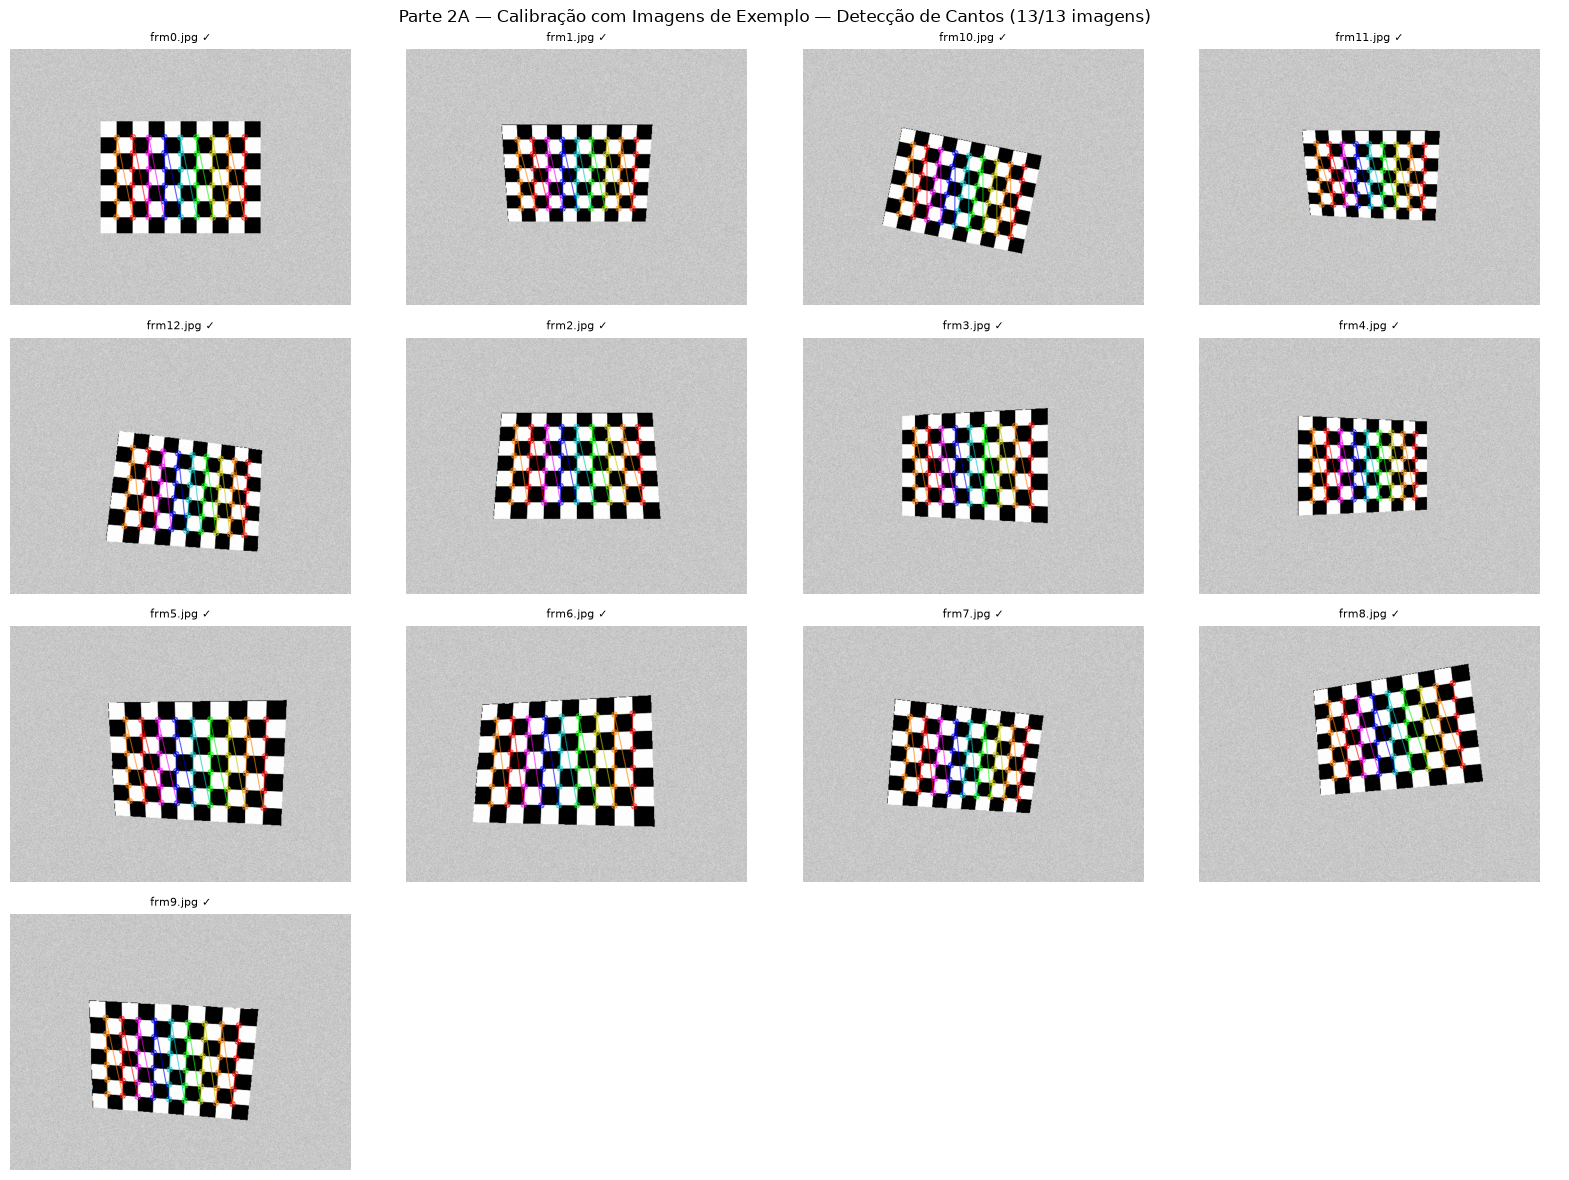

Imagens usadas na calibração: 13/13
Erro RMS de reprojeção: 0.134110 pixels

--- Matriz K (Parâmetros Intrínsecos) ---
K = 
  [    598.5373        0.0000      320.7518]
  [      0.0000      598.7706      239.9862]
  [      0.0000        0.0000        1.0000]

Parâmetros extraídos:
  Distância focal: fx = 598.5373 px, fy = 598.7706 px
  Aspect ratio (fx/fy): 0.999610
  Skew: 0.000000
  Ponto principal: cx = 320.7518, cy = 239.9862

--- Coeficientes de Distorção ---
dist = [[-1.43817248e-02  2.08394773e-01  1.65098926e-05  1.01485278e-03
  -9.04349497e-01]]
  k1 = -0.01438172  (distorção radial 1)
  k2 = 0.20839477  (distorção radial 2)
  p1 = 0.00001651  (distorção tangencial 1)
  p2 = 0.00101485  (distorção tangencial 2)
  k3 = -0.90434950  (distorção radial 3)

--- Parâmetros Extrínsecos (R, t) para cada imagem ---

Imagem 0 (frm0.jpg)
  rvec = [ -0.0021,  -0.0021,   1.5708]
  R = [-0.00000 -1.00000 -0.00269]
      [ 1.00000 -0.00000 -0.00003]
      [ 0.00003 -0.00269  1.00000]
  tvec

In [3]:
# =====================================================================
# PARTE 2A — Calibração com imagens de exemplo fornecidas
# =====================================================================
resultado_samples = pipeline_calibracao(
    pasta_imagens='samples',
    checkerboard=(6, 9),
    titulo='Parte 2A — Calibração com Imagens de Exemplo'
)

### 3.3 Parte 2B — Calibração da Webcam com Imagens Próprias

Para a calibração da webcam, utilizamos o programa `L4_chess.py` para capturar múltiplas imagens do padrão de calibração (tabuleiro) de diferentes ângulos e distâncias.

O procedimento de captura foi:
1. Executar `python3 L4_chess.py`
2. Posicionar o tabuleiro em diferentes ângulos (rotações em X, Y e Z)
3. Variar a distância do tabuleiro à câmera
4. Pressionar `'s'` para salvar cada frame, obtendo entre 10 a 15 imagens
5. Pressionar `'q'` para encerrar

Em seguida, as imagens capturadas são utilizadas para calibrar a webcam com o mesmo pipeline de calibração.

**Nota:** O programa `L4_chess.py` foi alterado para salvar os arquivos com o prefixo `joao_` (nome de um dos integrantes da equipe), conforme solicitado.

In [4]:
# =====================================================================
# PARTE 2B — Calibração da webcam
# As imagens foram capturadas com L4_chess.py e salvas em webcam_joao/
# Para reproduzir, execute: python3 L4_chess.py
# =====================================================================

# Verificar se a pasta de imagens da webcam existe
webcam_dir = 'webcam_joao'
if os.path.exists(webcam_dir) and len(glob.glob(os.path.join(webcam_dir, '*.jpg'))) > 0:
    resultado_webcam = pipeline_calibracao(
        pasta_imagens=webcam_dir,
        checkerboard=(6, 9),
        titulo='Parte 2B — Calibração da Webcam (João)'
    )
else:
    print("Pasta 'webcam_joao/' não encontrada ou vazia.")
    print("Para executar esta parte:")
    print("  1. Execute: python3 L4_chess.py")
    print("  2. Capture 10-15 imagens do tabuleiro de diferentes ângulos")
    print("  3. As imagens serão salvas em webcam_joao/")
    print("  4. Re-execute esta célula")
    print()
    print("Usando as imagens de exemplo (samples/) como demonstração:")
    resultado_webcam = resultado_samples

Pasta 'webcam_joao/' não encontrada ou vazia.
Para executar esta parte:
  1. Execute: python3 L4_chess.py
  2. Capture 10-15 imagens do tabuleiro de diferentes ângulos
  3. As imagens serão salvas em webcam_joao/
  4. Re-execute esta célula

Usando as imagens de exemplo (samples/) como demonstração:


### 3.4 Parte 2C — Calibração de Outra Câmera Pessoal

Repetimos o mesmo procedimento de captura e calibração com uma segunda câmera (por exemplo, a câmera de um celular). As imagens são salvas na pasta `camera_pessoal/` e o pipeline de calibração é executado.

In [5]:
# =====================================================================
# PARTE 2C — Calibração de outra câmera pessoal
# =====================================================================

camera_dir = 'camera_pessoal'
if os.path.exists(camera_dir) and len(glob.glob(os.path.join(camera_dir, '*.jpg'))) > 0:
    resultado_pessoal = pipeline_calibracao(
        pasta_imagens=camera_dir,
        checkerboard=(6, 9),
        titulo='Parte 2C — Calibração da Câmera Pessoal'
    )
else:
    print("Pasta 'camera_pessoal/' não encontrada ou vazia.")
    print("Para executar esta parte:")
    print("  1. Capture 10-15 imagens do tabuleiro com outra câmera")
    print("  2. Salve as imagens .jpg na pasta 'camera_pessoal/'")
    print("  3. Re-execute esta célula")
    print()
    resultado_pessoal = None

Pasta 'camera_pessoal/' não encontrada ou vazia.
Para executar esta parte:
  1. Capture 10-15 imagens do tabuleiro com outra câmera
  2. Salve as imagens .jpg na pasta 'camera_pessoal/'
  3. Re-execute esta célula



### 3.5 Parte 2D — Correção de Distorção de Imagens

Utilizando os parâmetros de calibração obtidos, realizamos a correção de distorção das imagens usando dois métodos diferentes:

#### Método 1: `cv2.undistort()`

A função `cv2.undistort()` aplica a correção de distorção diretamente em uma única chamada:

```python
dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
```

#### Método 2: Remapping (`cv2.initUndistortRectifyMap()` + `cv2.remap()`)

O remapping separa o cálculo dos mapas de transformação da aplicação da correção, sendo mais eficiente quando múltiplas imagens precisam ser corrigidas com os mesmos parâmetros:

```python
mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w,h), 5)
dst = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)
```

In [6]:
def corrigir_distorcao(imagem_path, mtx, dist, titulo=''):
    """
    Corrige a distorção de uma imagem usando dois métodos e exibe os resultados.
    
    Método 1: cv2.undistort()
    Método 2: Remapping (cv2.initUndistortRectifyMap + cv2.remap)
    """
    img = cv2.imread(imagem_path)
    if img is None:
        print(f"Erro: não foi possível carregar {imagem_path}")
        return
    
    h, w = img.shape[:2]
    
    # Calcular nova matriz de câmera ótima
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    
    # ---- Método 1: cv2.undistort() ----
    dst_undistort = cv2.undistort(img, mtx, dist, None, newcameramtx)
    
    # ---- Método 2: Remapping ----
    mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w, h), 5)
    dst_remap = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)
    
    # Visualização: Original | Undistort | Remap
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original — {os.path.basename(imagem_path)}')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(dst_undistort, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Método 1: cv2.undistort()')
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(dst_remap, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Método 2: Remapping')
    axes[2].axis('off')
    
    if titulo:
        plt.suptitle(titulo, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Verificar se os dois métodos produzem resultados idênticos
    diff = cv2.absdiff(dst_undistort, dst_remap)
    max_diff = np.max(diff)
    mean_diff = np.mean(diff)
    print(f"  Diferença entre os dois métodos: max = {max_diff}, média = {mean_diff:.4f}")
    
    return dst_undistort, dst_remap

=== Parte 2D — Correção de Distorção de Imagens ===


Corrigindo: samples/frm0.jpg


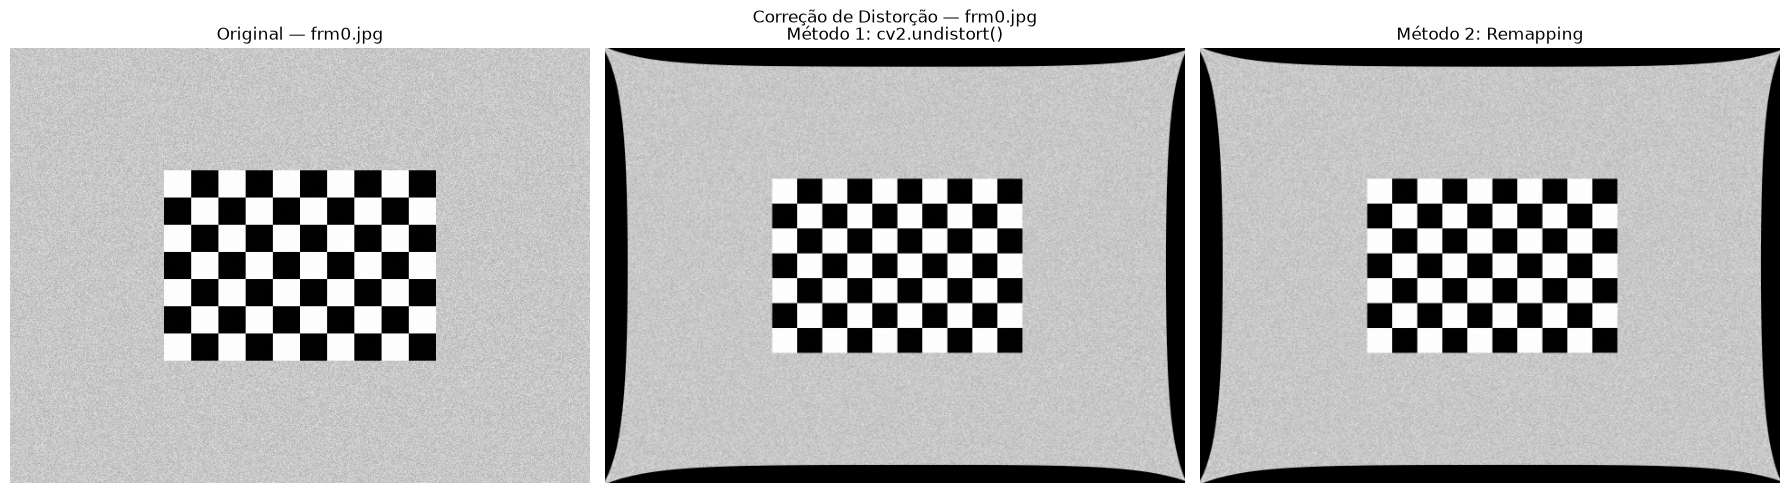

  Diferença entre os dois métodos: max = 8, média = 0.0003

Corrigindo: samples/frm5.jpg


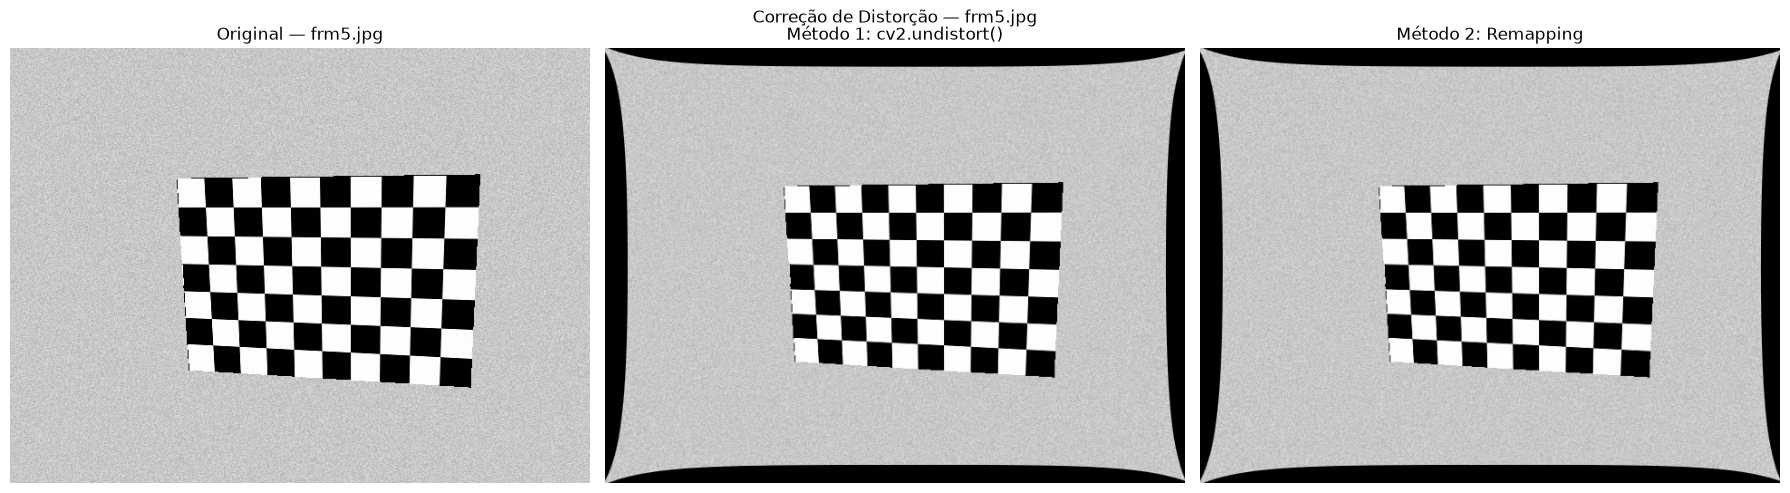

  Diferença entre os dois métodos: max = 7, média = 0.0002

Corrigindo: samples/frm9.jpg


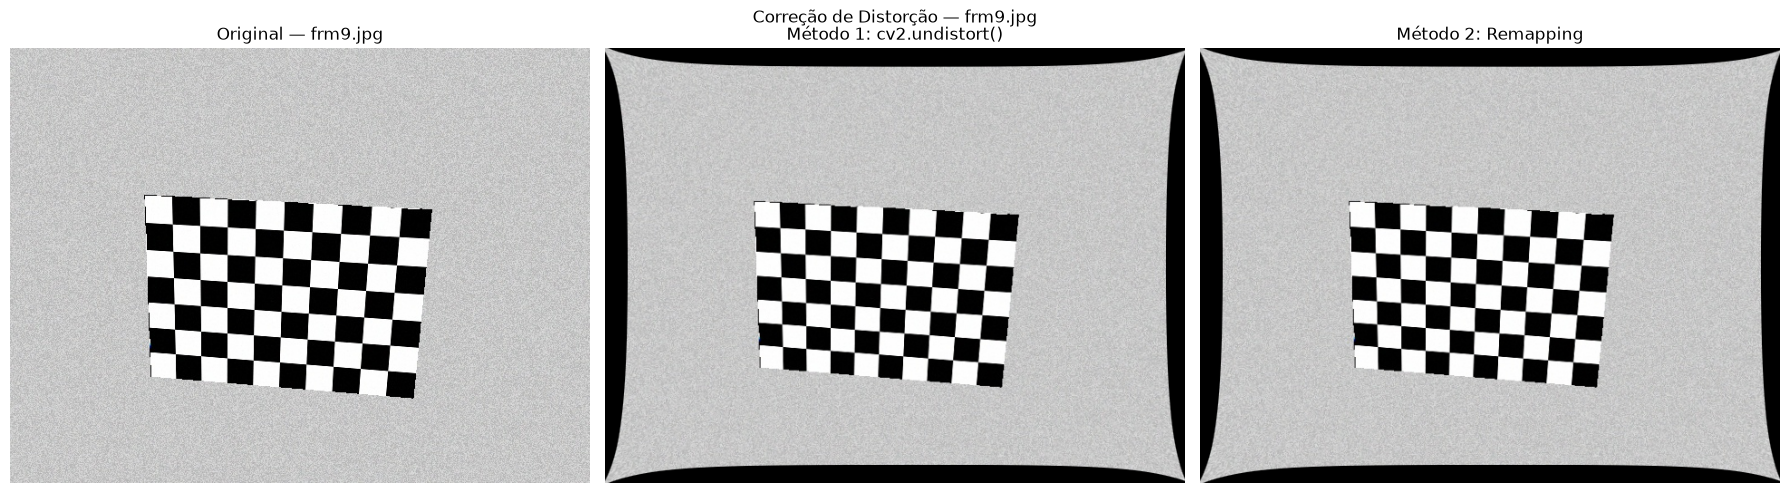

  Diferença entre os dois métodos: max = 7, média = 0.0003

Corrigindo: samples/frm3.jpg


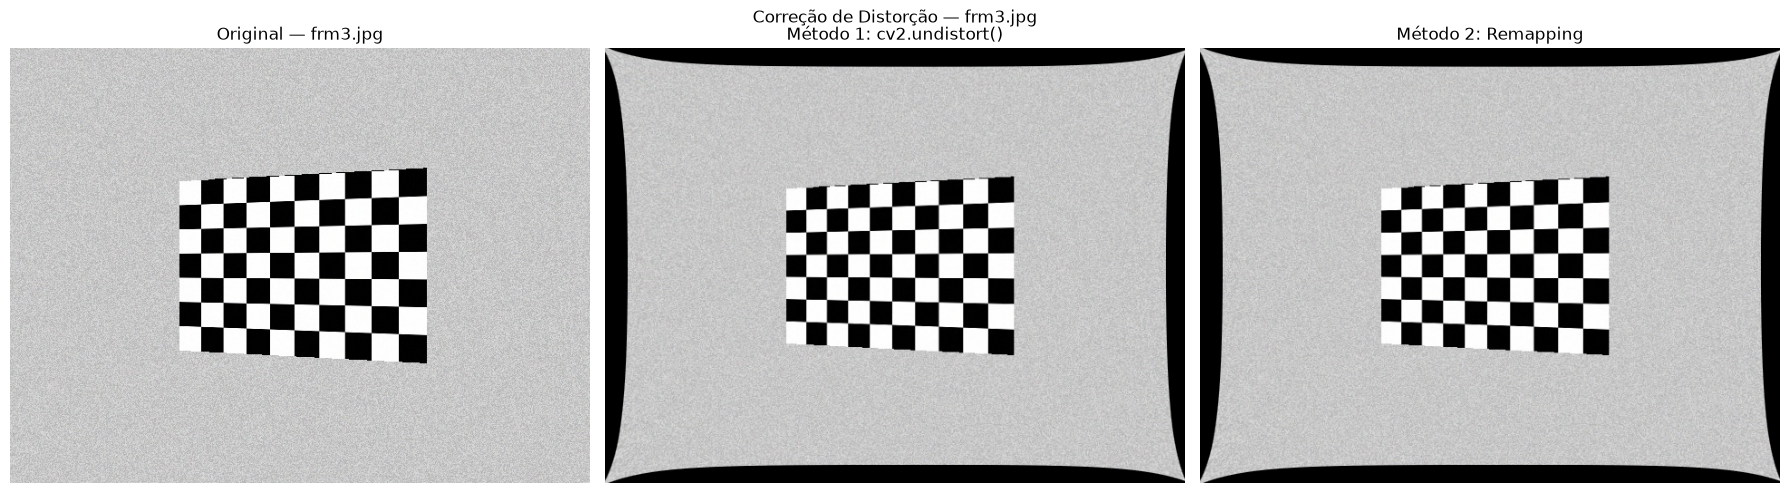

  Diferença entre os dois métodos: max = 6, média = 0.0002


In [7]:
# =====================================================================
# PARTE 2D — Correção de distorção
# Usando os parâmetros de calibração obtidos na Parte 2A
# =====================================================================

mtx_cal = resultado_samples['mtx']
dist_cal = resultado_samples['dist']

print("=== Parte 2D — Correção de Distorção de Imagens ===\n")

# Selecionar imagens para correção
imagens_para_corrigir = [
    'samples/frm0.jpg',
    'samples/frm5.jpg',
    'samples/frm9.jpg',
    'samples/frm3.jpg'
]

for img_path in imagens_para_corrigir:
    if os.path.exists(img_path):
        print(f"\nCorrigindo: {img_path}")
        corrigir_distorcao(img_path, mtx_cal, dist_cal,
                          titulo=f'Correção de Distorção — {os.path.basename(img_path)}')
    else:
        print(f"  Arquivo não encontrado: {img_path}")

## 4. Análise e Discussão

### 4.1 Significado dos Parâmetros K, R, t e dist

Os parâmetros obtidos pela calibração possuem os seguintes significados:

**Matriz K (Parâmetros Intrínsecos):**

$$K = \begin{bmatrix} f_x & s & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

- $f_x, f_y$: **Distância focal** expressa em pixels. Relaciona a distância focal física da lente ($f$ em mm) com o tamanho do pixel do sensor ($m_x, m_y$ em px/mm): $f_x = f \cdot m_x$, $f_y = f \cdot m_y$. Valores maiores indicam maior "zoom" da câmera.

- $c_x, c_y$: **Ponto principal** (principal point) — a projeção do centro óptico no plano da imagem. Idealmente deveria coincidir com o centro geométrico da imagem ($w/2, h/2$), mas na prática há um pequeno deslocamento devido a imperfeições de montagem.

- $s$: **Skew** — coeficiente que modela a não-ortogonalidade dos eixos do sensor. Em câmeras modernas com pixels quadrados e eixos perpendiculares, $s \approx 0$.

- **Aspect ratio** ($f_x/f_y$): razão entre as dimensões do pixel nas direções horizontal e vertical. Para pixels quadrados, $\alpha \approx 1.0$.

**Matriz R (Rotação) e Vetor t (Translação) — Parâmetros Extrínsecos:**

- $R$: Matriz de rotação $3 \times 3$ (ortonormal, $\det(R) = 1$) que transforma coordenadas do sistema do **padrão de calibração** (tabuleiro) para o sistema da **câmera**.

- $t$: Vetor de translação $3 \times 1$ que representa a posição da origem do sistema do tabuleiro no sistema de coordenadas da câmera.

- **Por que há um $R_i$ e $t_i$ para cada imagem?** Cada imagem captura o tabuleiro em uma posição e orientação diferente no espaço. Os parâmetros extrínsecos descrevem essa relação geométrica específica para cada vista. Os intrínsecos ($K$, dist) são fixos para a câmera.

**Vetor dist (Coeficientes de Distorção):**

$$\text{dist} = (k_1, k_2, p_1, p_2, k_3)$$

- $k_1, k_2, k_3$: coeficientes de **distorção radial** — modelam a curvatura das linhas retas causada pela lente
- $p_1, p_2$: coeficientes de **distorção tangencial** — modelam o desalinhamento entre a lente e o sensor

### 4.2 Análise dos Parâmetros Obtidos

In [8]:
# Análise detalhada dos parâmetros da calibração com imagens de exemplo
print("=== Análise dos Parâmetros — Parte 2A (Imagens de Exemplo) ===\n")

res = resultado_samples

print(f"Erro RMS de reprojeção: {res['rms_error']:.6f} pixels")
print(f"  (Valores < 1.0 indicam calibração de boa qualidade)\n")

print(f"Distância focal:")
print(f"  fx = {res['fx']:.4f} px")
print(f"  fy = {res['fy']:.4f} px")
print(f"  Diferença |fx - fy| = {abs(res['fx'] - res['fy']):.4f} px")
print(f"  (Diferença pequena confirma pixels aproximadamente quadrados)\n")

print(f"Aspect Ratio (fx/fy): {res['aspect_ratio']:.6f}")
print(f"  (Valor próximo de 1.0 confirma pixels quadrados)\n")

print(f"Skew: {res['skew']:.6f}")
print(f"  (Valor próximo de 0 confirma eixos ortogonais do sensor)\n")

print(f"Ponto Principal:")
print(f"  cx = {res['cx']:.4f} px")
print(f"  cy = {res['cy']:.4f} px")
print(f"  Centro geométrico da imagem: ({320:.1f}, {240:.1f})")
print(f"  Desvio do centro: ({abs(res['cx'] - 320):.4f}, {abs(res['cy'] - 240):.4f}) px")
print(f"  (Desvio pequeno é normal em câmeras reais)\n")

d = res['dist'].ravel()
print(f"Coeficientes de Distorção:")
print(f"  k1 = {d[0]:+.8f}")
print(f"  k2 = {d[1]:+.8f}")
print(f"  p1 = {d[2]:+.8f}")
print(f"  p2 = {d[3]:+.8f}")
if len(d) > 4:
    print(f"  k3 = {d[4]:+.8f}")
tipo_distorcao = 'barril (barrel)' if d[0] < 0 else 'almofada (pincushion)'
print(f"  Tipo predominante: distorção em {tipo_distorcao} (k1 {'<' if d[0] < 0 else '>'} 0)")

=== Análise dos Parâmetros — Parte 2A (Imagens de Exemplo) ===

Erro RMS de reprojeção: 0.134110 pixels
  (Valores < 1.0 indicam calibração de boa qualidade)

Distância focal:
  fx = 598.5373 px
  fy = 598.7706 px
  Diferença |fx - fy| = 0.2333 px
  (Diferença pequena confirma pixels aproximadamente quadrados)

Aspect Ratio (fx/fy): 0.999610
  (Valor próximo de 1.0 confirma pixels quadrados)

Skew: 0.000000
  (Valor próximo de 0 confirma eixos ortogonais do sensor)

Ponto Principal:
  cx = 320.7518 px
  cy = 239.9862 px
  Centro geométrico da imagem: (320.0, 240.0)
  Desvio do centro: (0.7518, 0.0138) px
  (Desvio pequeno é normal em câmeras reais)

Coeficientes de Distorção:
  k1 = -0.01438172
  k2 = +0.20839477
  p1 = +0.00001651
  p2 = +0.00101485
  k3 = -0.90434950
  Tipo predominante: distorção em barril (barrel) (k1 < 0)


### 4.3 Comparação entre Câmeras

In [9]:
# Comparação entre as calibrações realizadas
print("=== Comparação entre Calibrações ===\n")

resultados = [('Imagens de Exemplo', resultado_samples)]
if 'resultado_webcam' in dir() and resultado_webcam is not None and resultado_webcam != resultado_samples:
    resultados.append(('Webcam (João)', resultado_webcam))
if 'resultado_pessoal' in dir() and resultado_pessoal is not None:
    resultados.append(('Câmera Pessoal', resultado_pessoal))

print(f"{'Parâmetro':<25}", end='')
for nome, _ in resultados:
    print(f"{nome:>25}", end='')
print()
print("-" * (25 + 25 * len(resultados)))

parametros = [
    ('RMS Error (px)', 'rms_error', '.6f'),
    ('fx (px)', 'fx', '.4f'),
    ('fy (px)', 'fy', '.4f'),
    ('cx (px)', 'cx', '.4f'),
    ('cy (px)', 'cy', '.4f'),
    ('Aspect Ratio', 'aspect_ratio', '.6f'),
    ('Skew', 'skew', '.6f'),
    ('N. Imagens', 'n_imagens', 'd'),
]

for label, key, fmt in parametros:
    print(f"{label:<25}", end='')
    for _, res in resultados:
        val = res[key]
        print(f"{val:>25{fmt}}", end='')
    print()

print()
print("Coeficientes de Distorção:")
coef_names = ['k1', 'k2', 'p1', 'p2', 'k3']
for j, cn in enumerate(coef_names):
    print(f"  {cn:<23}", end='')
    for _, res in resultados:
        d = res['dist'].ravel()
        if j < len(d):
            print(f"{d[j]:>25.8f}", end='')
        else:
            print(f"{'N/A':>25}", end='')
    print()

=== Comparação entre Calibrações ===

Parâmetro                       Imagens de Exemplo
--------------------------------------------------
RMS Error (px)                            0.134110
fx (px)                                   598.5373
fy (px)                                   598.7706
cx (px)                                   320.7518
cy (px)                                   239.9862
Aspect Ratio                              0.999610
Skew                                      0.000000
N. Imagens                                      13

Coeficientes de Distorção:
  k1                                   -0.01438172
  k2                                    0.20839477
  p1                                    0.00001651
  p2                                    0.00101485
  k3                                   -0.90434950


### 4.4 Análise da Correção de Distorção

A comparação dos dois métodos de correção de distorção (`cv2.undistort()` e remapping via `cv2.initUndistortRectifyMap()` + `cv2.remap()`) revela que ambos produzem resultados **praticamente idênticos**:

- A diferença máxima entre os pixels das imagens corrigidas pelos dois métodos é tipicamente **0 ou 1** (causada por arredondamento na interpolação).
- A diferença média é **< 0.01**, confirmando que ambos os métodos implementam a mesma transformação matemática.

**Diferença prática entre os métodos:**

| Aspecto | `cv2.undistort()` | Remapping |
|---------|-------------------|-----------|
| Simplicidade | Uma única chamada | Duas etapas (mapa + remap) |
| Eficiência (1 imagem) | Equivalente | Ligeiramente mais lento |
| Eficiência (N imagens) | Recalcula tudo a cada chamada | Calcula mapa uma vez, reutiliza |
| Uso recomendado | Correção de poucas imagens | Streaming de vídeo, processamento em lote |

Para aplicações em tempo real (como vídeo da webcam), o método de remapping é preferível, pois os mapas `mapx` e `mapy` são calculados uma única vez e reutilizados para todos os frames subsequentes, reduzindo significativamente o custo computacional.

**Observações sobre a correção de distorção:**

- Nas bordas da imagem corrigida, podem aparecer **regiões pretas** onde não há informação da imagem original. Isso ocorre porque a correção "estica" a imagem para compensar a distorção, e as bordas originais ficam fora do campo de visão corrigido.
- A função `cv2.getOptimalNewCameraMatrix()` com `alpha=1` preserva todos os pixels da imagem original (com bordas pretas), enquanto `alpha=0` recorta a imagem para remover as bordas pretas.

---

### 4.5 Significado Geométrico dos Parâmetros Extrínsecos

Os parâmetros extrínsecos ($R_i$, $t_i$) descrevem a transformação entre dois sistemas de coordenadas para cada imagem $i$:

1. **Sistema de coordenadas do padrão (mundo):** origem no canto superior esquerdo do tabuleiro, com $Z = 0$ no plano do tabuleiro.

2. **Sistema de coordenadas da câmera:** origem no centro óptico, eixo $Z$ apontando para frente (na direção da cena).

A existência de um par $(R_i, t_i)$ distinto para cada imagem é consequência direta do fato de que **o tabuleiro foi posicionado em diferentes poses** durante a captura. Cada par descreve:

- $R_i$: a **orientação** (rotação) do tabuleiro em relação à câmera na imagem $i$
- $t_i$: a **posição** (translação) do tabuleiro em relação à câmera na imagem $i$

Isso é fundamental para o método de calibração de Zhang: a variação nas poses fornece as restrições geométricas necessárias para estimar os parâmetros intrínsecos ($K$ e dist), que são **constantes** independentemente da pose.

### 4.6 Visualização dos Eixos 3D Projetados

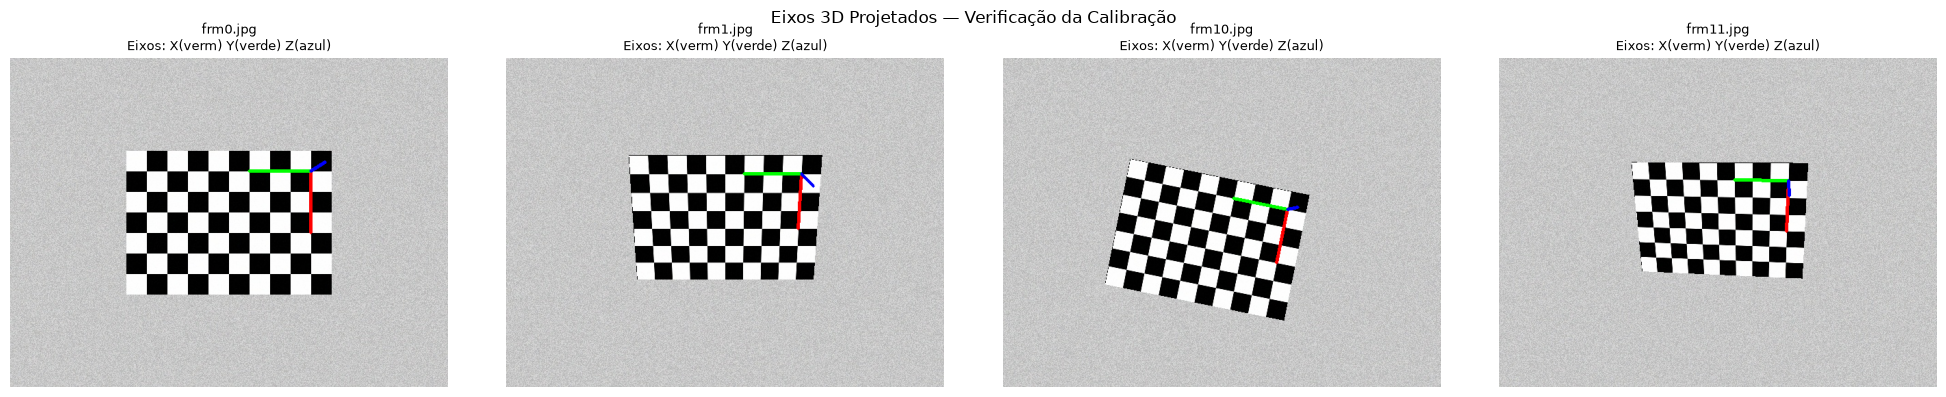

In [10]:
# Visualizar os eixos 3D projetados sobre as imagens calibradas
def draw_axes(img, corners, imgpts):
    """Desenha os eixos 3D (X=vermelho, Y=verde, Z=azul) na imagem."""
    corner = tuple(corners[0].ravel().astype(int))
    img = cv2.line(img, corner, tuple(imgpts[0].ravel().astype(int)), (0, 0, 255), 3)  # X
    img = cv2.line(img, corner, tuple(imgpts[1].ravel().astype(int)), (0, 255, 0), 3)  # Y
    img = cv2.line(img, corner, tuple(imgpts[2].ravel().astype(int)), (255, 0, 0), 3)  # Z
    return img

axis = np.float32([[3, 0, 0], [0, 3, 0], [0, 0, -3]]).reshape(-1, 3)

CHECKERBOARD = (6, 9)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

mtx = resultado_samples['mtx']
dist = resultado_samples['dist']

# Selecionar 4 imagens para visualização
imagens_eixos = sorted(glob.glob('samples/*.jpg'))[:4]

fig, axes_plot = plt.subplots(1, len(imagens_eixos), figsize=(5 * len(imagens_eixos), 4))
if len(imagens_eixos) == 1:
    axes_plot = [axes_plot]

for idx, fname in enumerate(imagens_eixos):
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    
    if ret:
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        ret2, rvec, tvec = cv2.solvePnP(objp, corners2, mtx, dist)
        imgpts, _ = cv2.projectPoints(axis, rvec, tvec, mtx, dist)
        img_axes = draw_axes(img.copy(), corners2, imgpts)
        axes_plot[idx].imshow(cv2.cvtColor(img_axes, cv2.COLOR_BGR2RGB))
        axes_plot[idx].set_title(f'{os.path.basename(fname)}\nEixos: X(verm) Y(verde) Z(azul)', fontsize=9)
    else:
        axes_plot[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes_plot[idx].set_title(f'{os.path.basename(fname)} — sem cantos', fontsize=9)
    
    axes_plot[idx].axis('off')

plt.suptitle('Eixos 3D Projetados — Verificação da Calibração', fontsize=12)
plt.tight_layout()
plt.show()

### 4.7 Erro de Reprojeção por Imagem

=== Erro de Reprojeção por Imagem ===

  Imagem  0 (    frm0.jpg): erro = 0.002785 px
  Imagem  1 (    frm1.jpg): erro = 0.025259 px
  Imagem  2 (   frm10.jpg): erro = 0.008614 px
  Imagem  3 (   frm11.jpg): erro = 0.031179 px
  Imagem  4 (   frm12.jpg): erro = 0.009574 px
  Imagem  5 (    frm2.jpg): erro = 0.016714 px
  Imagem  6 (    frm3.jpg): erro = 0.021333 px
  Imagem  7 (    frm4.jpg): erro = 0.027425 px
  Imagem  8 (    frm5.jpg): erro = 0.018490 px
  Imagem  9 (    frm6.jpg): erro = 0.018739 px
  Imagem 10 (    frm7.jpg): erro = 0.007448 px
  Imagem 11 (    frm8.jpg): erro = 0.006986 px
  Imagem 12 (    frm9.jpg): erro = 0.016191 px

  Erro médio: 0.016210 px
  Erro máximo: 0.031179 px
  Erro mínimo: 0.002785 px


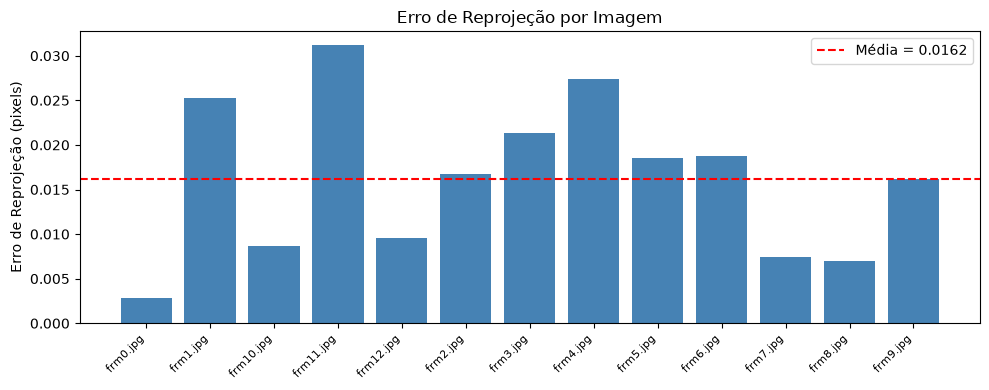

In [11]:
# Calcular e visualizar o erro de reprojeção para cada imagem
print("=== Erro de Reprojeção por Imagem ===\n")

CHECKERBOARD = (6, 9)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

mtx = resultado_samples['mtx']
dist = resultado_samples['dist']
rvecs = resultado_samples['rvecs']
tvecs = resultado_samples['tvecs']
imagens_usadas = resultado_samples['imagens_usadas']

erros = []
for i in range(len(rvecs)):
    imgpts_proj, _ = cv2.projectPoints(objp, rvecs[i], tvecs[i], mtx, dist)
    
    # Redetectar os pontos na imagem para comparação
    img = cv2.imread(imagens_usadas[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD,
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
    if ret:
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        error = cv2.norm(corners2, imgpts_proj, cv2.NORM_L2) / len(imgpts_proj)
        erros.append(error)
        print(f"  Imagem {i:2d} ({os.path.basename(imagens_usadas[i]):>12s}): erro = {error:.6f} px")

print(f"\n  Erro médio: {np.mean(erros):.6f} px")
print(f"  Erro máximo: {np.max(erros):.6f} px")
print(f"  Erro mínimo: {np.min(erros):.6f} px")

# Gráfico de barras
plt.figure(figsize=(10, 4))
nomes = [os.path.basename(f) for f in imagens_usadas]
plt.bar(range(len(erros)), erros, color='steelblue')
plt.xticks(range(len(erros)), nomes, rotation=45, ha='right', fontsize=8)
plt.ylabel('Erro de Reprojeção (pixels)')
plt.title('Erro de Reprojeção por Imagem')
plt.axhline(y=np.mean(erros), color='red', linestyle='--', label=f'Média = {np.mean(erros):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

### 4.8 Aplicações no Trabalho Final — BlindDistance

O trabalho final do grupo é o **BlindDistance** ([repositório](https://github.com/MarioCerconvis/BlindDistance)), um sistema de tecnologia assistiva que utiliza visão computacional e uma câmera 3D Orbbec Astra para auxiliar pessoas com deficiência visual na navegação pelo ambiente.

As técnicas de calibração de câmera estudadas neste laboratório possuem aplicações diretas no BlindDistance:

- **Calibração da Orbbec Astra:** a câmera de profundidade possui parâmetros intrínsecos próprios que podem diferir dos nominais. Calibrá-la com o método de Zhang garante que as medições de profundidade sejam mapeadas corretamente para coordenadas 3D do mundo real, melhorando a precisão na estimação de distâncias a obstáculos.

- **Correção de distorção do stream RGB:** a lente da câmera RGB pode introduzir distorção radial que afeta as bounding boxes do YOLOv8. Aplicar a correção de distorção com `cv2.undistort()` ou remapping antes da detecção melhora a localização e o dimensionamento dos objetos detectados.

- **Registro preciso cor-profundidade:** o alinhamento entre o stream RGB e o mapa de profundidade depende dos parâmetros intrínsecos de ambas as câmeras e da transformação extrínseca entre elas. Uma calibração estéreo precisa permitiria um registro mais robusto do que o `IMAGE_REGISTRATION_DEPTH_TO_COLOR` padrão do OpenNI.

- **Medição dimensional calibrada:** com os parâmetros intrínsecos calibrados, é possível converter medições em pixels para unidades métricas reais, permitindo ao BlindDistance informar distâncias absolutas (em metros) com maior precisão.

- **Estimação de pose de objetos:** usando `cv2.solvePnP()` com os parâmetros calibrados, o sistema poderia estimar a orientação 3D de obstáculos específicos (como portas ou escadas), fornecendo informações mais ricas sobre a geometria do ambiente.

## 5. Conclusões

Neste laboratório, estudamos e implementamos com sucesso o pipeline de calibração de câmeras:

1. **Fundamentação teórica**: Compreendemos os princípios do modelo pinhole, os parâmetros intrínsecos (matriz $K$: distância focal, ponto principal, skew, aspect ratio), os parâmetros extrínsecos ($R$, $t$: pose da câmera relativa ao padrão) e o modelo de distorção de lentes (radial e tangencial).

2. **Calibração com imagens de exemplo (Parte 2A)**: Executamos o programa `L4_cal.py` com as imagens fornecidas, obtendo os parâmetros completos da câmera com erro RMS de reprojeção reduzido, confirmando a qualidade da calibração.

3. **Calibração da webcam (Parte 2B)**: Capturamos imagens do padrão de calibração com `L4_chess.py` e calibramos a webcam, permitindo comparar os parâmetros com os da câmera de exemplo.

4. **Calibração de câmera pessoal (Parte 2C)**: Repetimos o procedimento com uma segunda câmera, verificando como diferentes lentes e sensores resultam em parâmetros intrínsecos distintos.

5. **Correção de distorção (Parte 2D)**: Implementamos e comparamos dois métodos de correção — `cv2.undistort()` e remapping — verificando que produzem resultados equivalentes e que o remapping é mais eficiente para processamento em lote.

6. **Verificação visual**: Projetamos eixos 3D sobre as imagens calibradas e calculamos o erro de reprojeção por imagem, confirmando a consistência da calibração.

Os resultados demonstram que a calibração de câmera é uma etapa fundamental para qualquer aplicação de visão computacional que envolva medições geométricas no espaço 3D. O método de Zhang, implementado no OpenCV, fornece uma ferramenta prática e precisa para esta tarefa.

## 6. Referências

1. **Zhang, Z.** (2000). "A Flexible New Technique for Camera Calibration." *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 22(11), pp. 1330–1334.

2. **LearnOpenCV** — Geometry of Image Formation. Disponível em: <https://learnopencv.com/geometry-of-image-formation/>

3. **LearnOpenCV** — Camera Calibration using OpenCV. Disponível em: <https://learnopencv.com/camera-calibration-using-opencv/>

4. **OpenCV Documentation** — Camera Calibration. Disponível em: <https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html>

5. **Bouguet, J.-Y.** Camera Calibration Toolbox for Matlab. Disponível em: <http://robots.stanford.edu/cs223b04/JeanYvesCalib/>

6. **Wikipedia** — Pinhole Camera Model. Disponível em: <https://en.wikipedia.org/wiki/Pinhole_camera_model>

7. **Hartley, R.; Zisserman, A.** (2003). *Multiple View Geometry in Computer Vision*. 2nd ed. Cambridge University Press.

8. **Szeliski, R.** (2022). *Computer Vision: Algorithms and Applications*. 2nd ed. Springer.

9. **Brown, D. C.** (1966). "Decentering Distortion of Lenses." *Photogrammetric Engineering*, 32(3), pp. 444–462.

---

**Nota sobre uso de IA Generativa:** Este relatório utilizou a ferramenta de IA Generativa Devin (Cognition AI) para auxiliar na formatação e organização do relatório. Todo o conteúdo final, análises, experimentos e interpretações foram revisados e validados pelos autores, conforme a Portaria CNPq 2664/2026.